Clustering Analysis (Unsupervised Learning)

Three approaches, run at the subject level:
1. PCA biplot
2. K-Means clustering (silhouette/elbow sweep to choose k)
3. Hierarchical clustering (Ward-linkage dendrogram colored by true status)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

PALETTE = {
    # binary
    "PD":       "#E24B4A",   # red-400
    "Healthy":  "#378ADD",   # blue-400
    # classifiers
    "SVM":      "#7F77DD",   # purple-400
    "HGB":      "#1D9E75",   # teal-400
    "LR":       "#BA7517",   # amber-600
    "RF":       "#B07FC8",   # soft purple
    # feature subsets
    "All":      "#D4537E",   # pink-400
    "JS":       "#639922",   # green-400  (jitter+shimmer)
}
ALPHA_WITH    = 1.00
ALPHA_WITHOUT = 0.45

plt.rcParams.update({
    "figure.dpi":      150,
    "font.family":     "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

COL_C0 = '#e08b3b'   # cluster 0
COL_C1 = '#5a9e6f'   # cluster 1

# Load data
# df = pd.read_csv('../../data/2025_parkinsons.csv')
# df['subject'] = df['name'].str.rsplit('_', n=1).str[0]
# df = df.dropna().reset_index(drop=True)

train_b = pd.read_csv('../../data/train_b.csv')
test_b  = pd.read_csv('../../data/test_b.csv')
df = pd.concat([train_b, test_b], ignore_index=True)
df['subject'] = df['name'].str.rsplit('_', n=1).str[0]


features = [c for c in df.columns if c not in ['name', 'subject', 'status']]
y_true   = df['status'].values.astype(int)   # recording-level labels

# Subject-level: mean feature vectors + one label per subject
df_grouped      = df.groupby('subject')[features].mean().reset_index()
df_grouped['status'] = df.groupby('subject')['status'].first().values
y_true_grouped  = df_grouped['status'].values.astype(int)
subject_ids     = df_grouped['subject'].values

print(f'Subjects: {len(df_grouped)}  |  Features: {len(features)}')
print(f'Subject-level PD: {(y_true_grouped==1).sum()}  |  Healthy: {(y_true_grouped==0).sum()}')
print(f'Recordings PD: {(y_true==1).sum()}  |  Healthy: {(y_true==0).sum()}')

Subjects: 32  |  Features: 22
Subject-level PD: 24  |  Healthy: 8
Recordings PD: 142  |  Healthy: 45


In [4]:
LOG_FEATS = [
    'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'RPDE', 'D2', 'PPE',
]

def apply_log(X_df):
    """Log-transform skewed features where all values are strictly positive."""
    X = X_df.copy()
    for f in LOG_FEATS:
        if f in X.columns and (X[f] > 0).all():
            X[f] = np.log(X[f])
    return X

def cluster_purity(y_true, cluster_labels):
    """Majority-class fraction across all clusters."""
    total = 0
    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        total += np.bincount(y_true[mask]).max()
    return total / len(y_true)

# subject-level feature matrix 
X_raw_subj    = apply_log(df_grouped[features])
scaler_subj   = StandardScaler()
X_scaled_subj = scaler_subj.fit_transform(X_raw_subj)

# recording level feature matrix 
X_raw_rec    = apply_log(df[features])
scaler_rec   = StandardScaler()
X_scaled_rec = scaler_rec.fit_transform(X_raw_rec)

# PCA separate instances for each unit
pca_subj      = PCA()
X_pca_subj    = pca_subj.fit_transform(X_scaled_subj)
ev_subj       = pca_subj.explained_variance_ratio_

pca_rec       = PCA()
X_pca_rec     = pca_rec.fit_transform(X_scaled_rec)
ev_rec        = pca_rec.explained_variance_ratio_

print('Subject-level PCA:')
print(f'  PC1 {ev_subj[0]*100:.1f}%  PC2 {ev_subj[1]*100:.1f}%  combined {(ev_subj[0]+ev_subj[1])*100:.1f}%')
print(f'  PCs needed for 80% variance: {(np.cumsum(ev_subj) < 0.80).sum() + 1}')
print('Recording-level PCA:')
print(f'  PC1 {ev_rec[0]*100:.1f}%  PC2 {ev_rec[1]*100:.1f}%  combined {(ev_rec[0]+ev_rec[1])*100:.1f}%')

Subject-level PCA:
  PC1 62.5%  PC2 12.5%  combined 75.0%
  PCs needed for 80% variance: 3
Recording-level PCA:
  PC1 59.3%  PC2 10.9%  combined 70.2%


Subject-Level Analysis

All metrics below are computed over 32 subject mean vectors -> one row per patient

PCA Biplot (Subjects)

PC1 vs PC2 colored by true diagnosis. Arrows show the top-8 loading vectors.

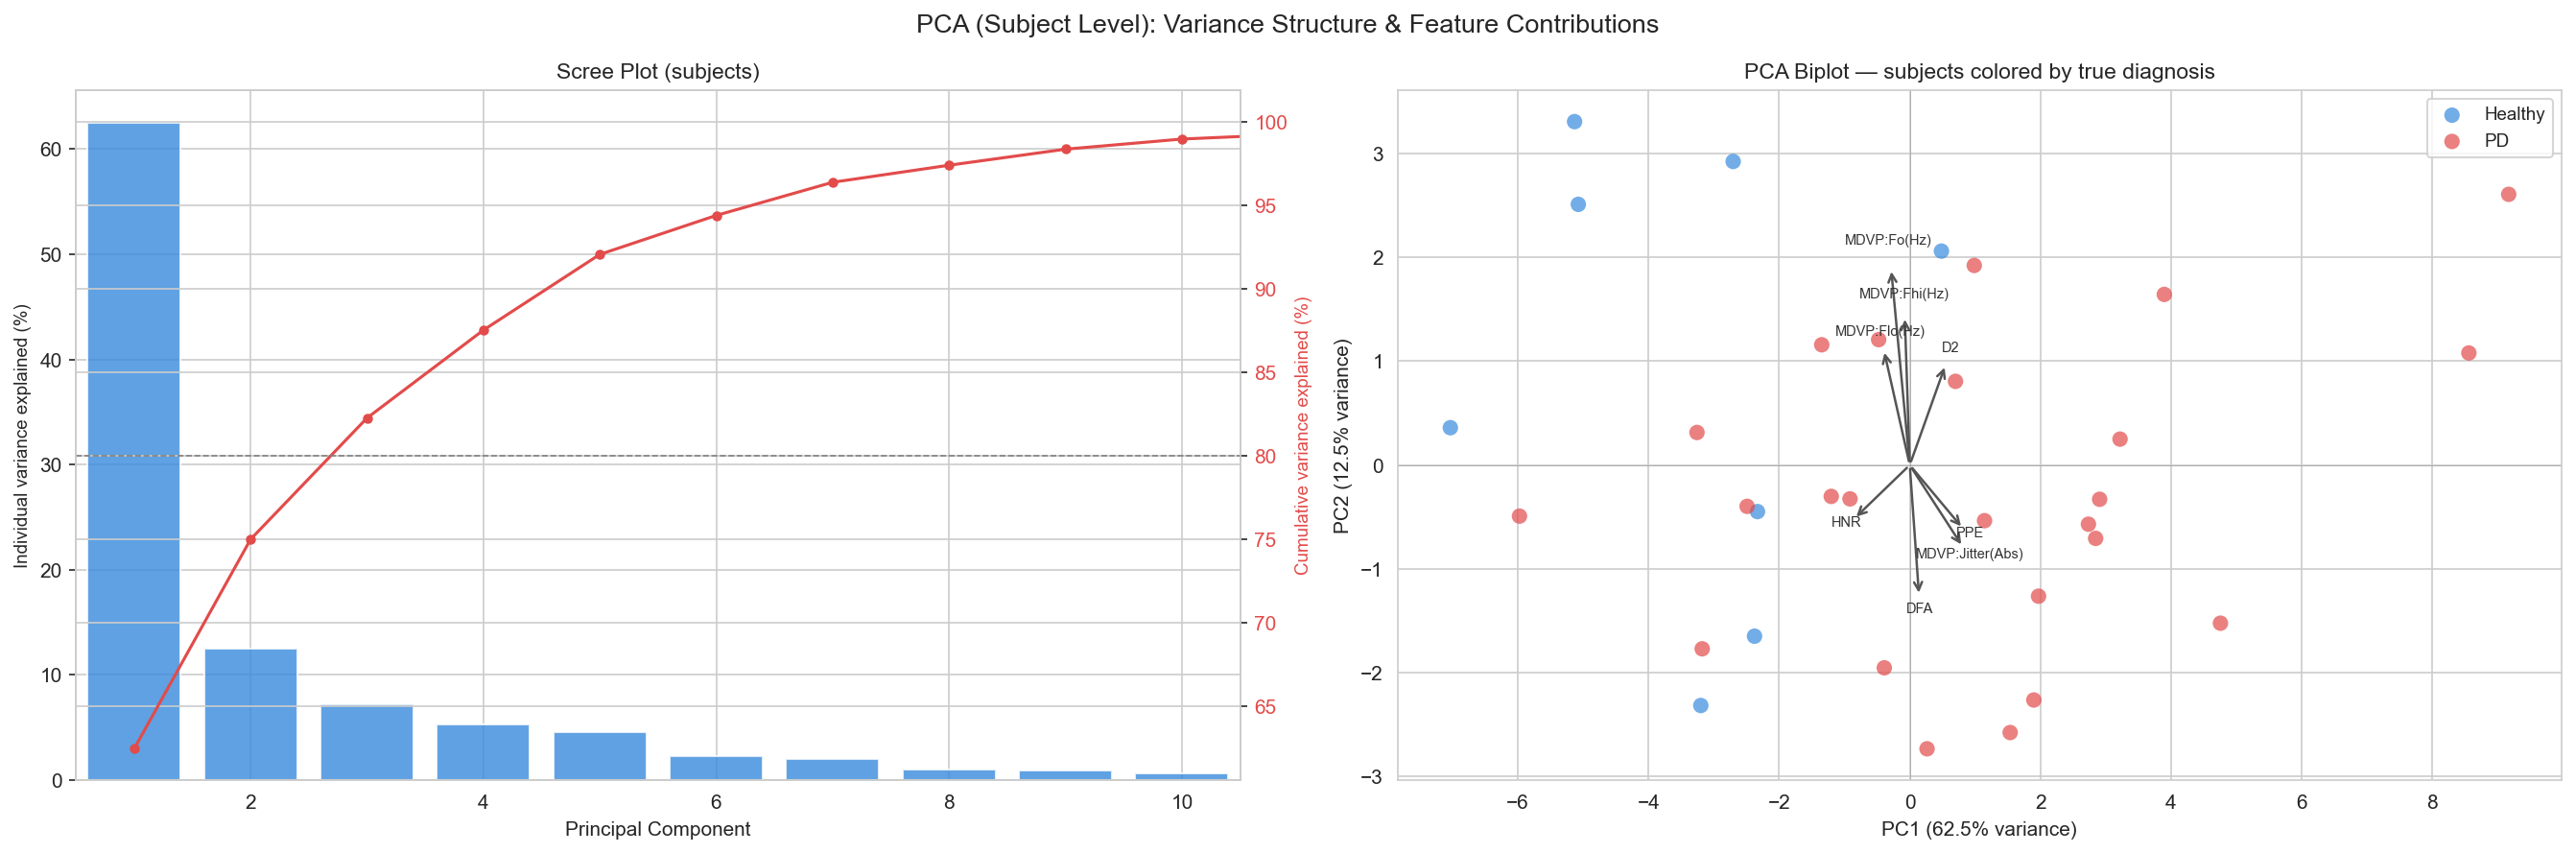

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
ax = axes[0]
cumvar = np.cumsum(ev_subj)
ax.bar(range(1, len(ev_subj)+1), ev_subj*100,
       color=PALETTE["Healthy"], alpha=0.8, edgecolor='white', label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(ev_subj)+1), cumvar*100,
         color=PALETTE["PD"], marker='o', markersize=4, linewidth=1.5, label='Cumulative')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Cumulative variance explained (%)', color=PALETTE["PD"], fontsize=9)
ax2.tick_params(axis='y', labelcolor=PALETTE["PD"])
ax.set_xlabel('Principal Component')
ax.set_ylabel('Individual variance explained (%)', fontsize=9)
ax.set_title('Scree Plot (subjects)', fontsize=11)
ax.set_xlim(0.5, min(10, len(ev_subj)) + 0.5)

# PCA biplot
ax = axes[1]
for g, label, color in [(0, 'Healthy', PALETTE["Healthy"]), (1, 'PD', PALETTE["PD"])]:
    m = y_true_grouped == g
    ax.scatter(X_pca_subj[m, 0], X_pca_subj[m, 1],
               c=color, label=label, alpha=0.7, s=60, edgecolors='none')

loadings_subj = pca_subj.components_[:2].T
magnitudes    = np.linalg.norm(loadings_subj, axis=1)
top_idx       = np.argsort(magnitudes)[::-1][:8]
scale = 3.5
for i in top_idx:
    ax.annotate('', xy=(loadings_subj[i,0]*scale, loadings_subj[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
    ax.text(loadings_subj[i,0]*scale*1.12, loadings_subj[i,1]*scale*1.12,
            features[i], fontsize=7, color='#333333', ha='center')

ax.set_xlabel(f'PC1 ({ev_subj[0]*100:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({ev_subj[1]*100:.1f}% variance)', fontsize=10)
ax.set_title('PCA Biplot — subjects colored by true diagnosis', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='grey', linewidth=0.4, alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.4, alpha=0.5)

fig.suptitle('PCA (Subject Level): Variance Structure & Feature Contributions', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/clustering_pca_biplot_subject.png', dpi=200, bbox_inches='tight')
plt.show()

K-Means: Choosing k (Subjects)

Silhouette score and elbow method over k = 2 … 8 on subject mean vectors

Best silhouette score: 0.299 at k=2
  k=2  silhouette=0.299
  k=3  silhouette=0.298
  k=4  silhouette=0.241
  k=5  silhouette=0.218
  k=6  silhouette=0.206
  k=7  silhouette=0.214
  k=8  silhouette=0.210


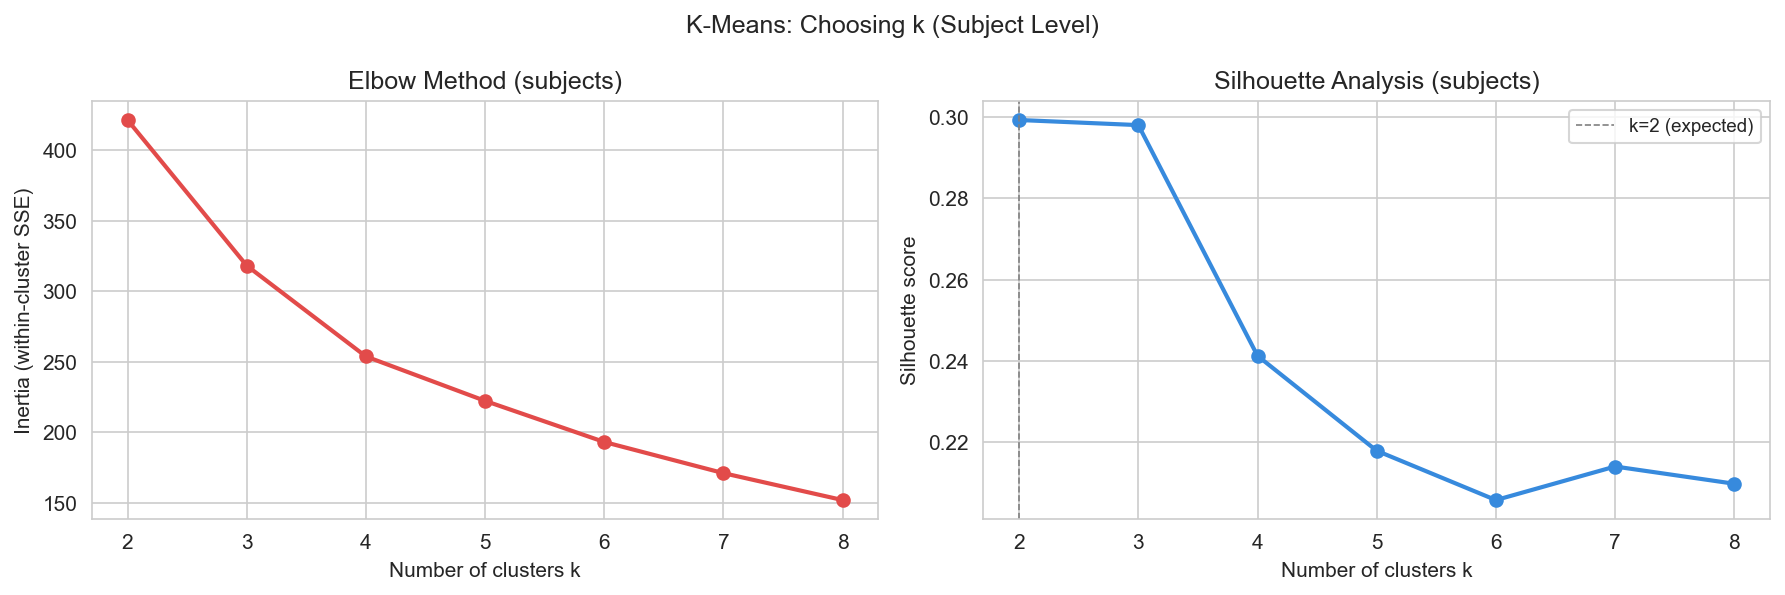

In [6]:
k_range_subj     = range(2, 9)
inertias_subj    = []
silhouettes_subj = []

for k in k_range_subj:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled_subj)
    inertias_subj.append(km.inertia_)
    silhouettes_subj.append(silhouette_score(X_scaled_subj, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range_subj), inertias_subj, 'o-', color=PALETTE["PD"], linewidth=2)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method (subjects)')
axes[0].set_xticks(list(k_range_subj))

axes[1].plot(list(k_range_subj), silhouettes_subj, 'o-', color=PALETTE["Healthy"], linewidth=2)
axes[1].axvline(2, color='grey', linestyle='--', linewidth=0.8, label='k=2 (expected)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Analysis (subjects)')
axes[1].set_xticks(list(k_range_subj))
axes[1].legend(fontsize=9)

best_k_subj = list(k_range_subj)[np.argmax(silhouettes_subj)]
print(f'Best silhouette score: {max(silhouettes_subj):.3f} at k={best_k_subj}')
for k, s in zip(k_range_subj, silhouettes_subj):
    print(f'  k={k}  silhouette={s:.3f}')

fig.suptitle('K-Means: Choosing k (Subject Level)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/clustering_silhouette_subject.png', dpi=200, bbox_inches='tight')
plt.show()

K-Means k=2 (Subjects)

Evaluation metrics against true subject-level labels:
- ARI: chance-corrected cluster/label agreement (0 = random, 1 = perfect)
- Purity: majority-class fraction across clusters
- Confusion matrix: best-permutation alignment of cluster IDs to true classes

K-Means k=2 — SUBJECT LEVEL
  Adjusted Rand Index (ARI) : 0.119
  Silhouette score          : 0.299
  Cluster purity            : 0.750

Cluster composition:
  Cluster 0: 16 subjects, PD=15, Healthy=1
  Cluster 1: 16 subjects, PD=9, Healthy=7


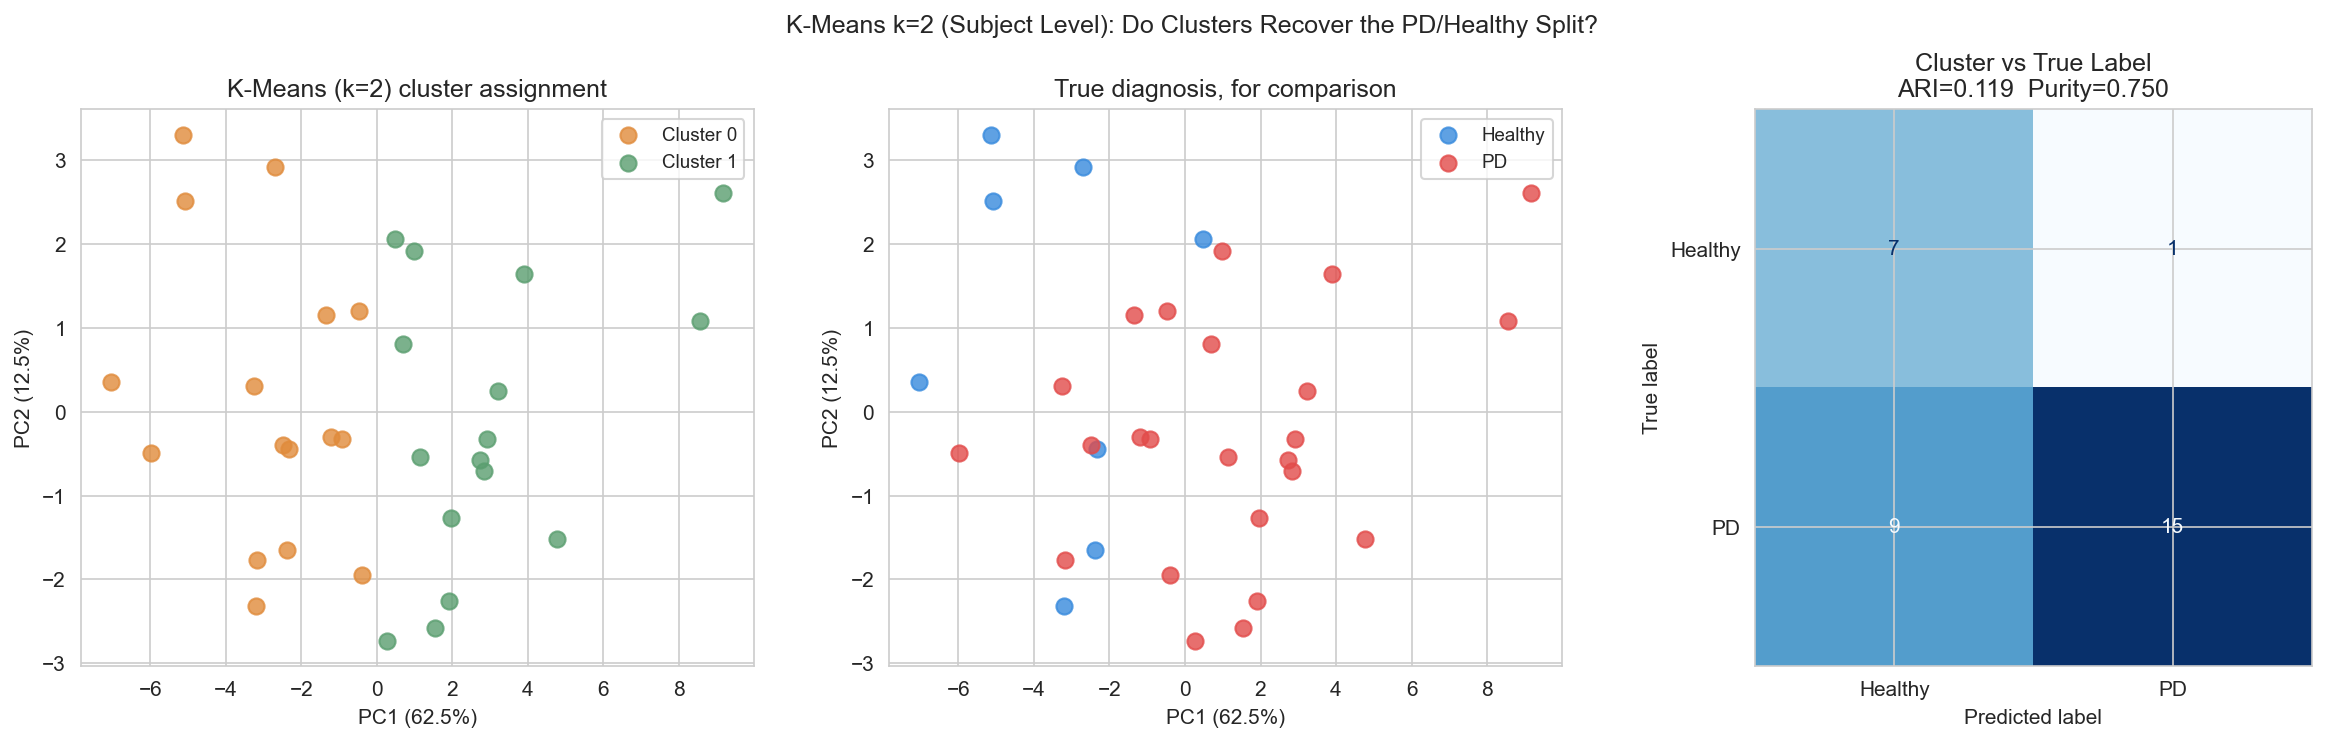

In [7]:
km2_subj          = KMeans(n_clusters=2, random_state=42, n_init=50)
cluster_labels_subj = km2_subj.fit_predict(X_scaled_subj)

ari_subj    = adjusted_rand_score(y_true_grouped, cluster_labels_subj)
sil_subj    = silhouette_score(X_scaled_subj, cluster_labels_subj)
purity_subj = cluster_purity(y_true_grouped, cluster_labels_subj)

# Best-alignment confusion matrix
cm0 = confusion_matrix(y_true_grouped, cluster_labels_subj)
cm1 = confusion_matrix(y_true_grouped, 1 - cluster_labels_subj)
acc0 = (cm0[0,0] + cm0[1,1]) / cm0.sum()
acc1 = (cm1[0,0] + cm1[1,1]) / cm1.sum()
best_cm_subj     = cm0 if acc0 >= acc1 else cm1
best_labels_subj = cluster_labels_subj if acc0 >= acc1 else 1 - cluster_labels_subj

print('K-Means k=2 — SUBJECT LEVEL')
print(f'  Adjusted Rand Index (ARI) : {ari_subj:.3f}')
print(f'  Silhouette score          : {sil_subj:.3f}')
print(f'  Cluster purity            : {purity_subj:.3f}')
print()
print('Cluster composition:')
for c in [0, 1]:
    mask = cluster_labels_subj == c
    n_pd = (y_true_grouped[mask] == 1).sum()
    n_he = (y_true_grouped[mask] == 0).sum()
    print(f'  Cluster {c}: {mask.sum()} subjects, PD={n_pd}, Healthy={n_he}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PCA scatter — cluster assignment
ax = axes[0]
for c, label, color in [(0, 'Cluster 0', COL_C0), (1, 'Cluster 1', COL_C1)]:
    m = best_labels_subj == c
    ax.scatter(X_pca_subj[m, 0], X_pca_subj[m, 1], c=color, label=label, alpha=0.8, s=60)
ax.set_xlabel(f'PC1 ({ev_subj[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev_subj[1]*100:.1f}%)')
ax.set_title('K-Means (k=2) cluster assignment')
ax.legend(fontsize=9)

# PCA scatter — true label
ax = axes[1]
for g, label, color in [(0, 'Healthy', PALETTE["Healthy"]), (1, 'PD', PALETTE["PD"])]:
    m = y_true_grouped == g
    ax.scatter(X_pca_subj[m, 0], X_pca_subj[m, 1], c=color, label=label, alpha=0.8, s=60)
ax.set_xlabel(f'PC1 ({ev_subj[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev_subj[1]*100:.1f}%)')
ax.set_title('True diagnosis, for comparison')
ax.legend(fontsize=9)

# Confusion matrix
ax = axes[2]
disp = ConfusionMatrixDisplay(best_cm_subj, display_labels=['Healthy', 'PD'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Cluster vs True Label\nARI={ari_subj:.3f}  Purity={purity_subj:.3f}')

fig.suptitle('K-Means k=2 (Subject Level): Do Clusters Recover the PD/Healthy Split?', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/clustering_kmeans_k2_subject.png', dpi=200, bbox_inches='tight')
plt.show()

Hierarchical Clustering (Subjects)

Ward linkage over subject mean vectors, leaves colored by true diagnosis

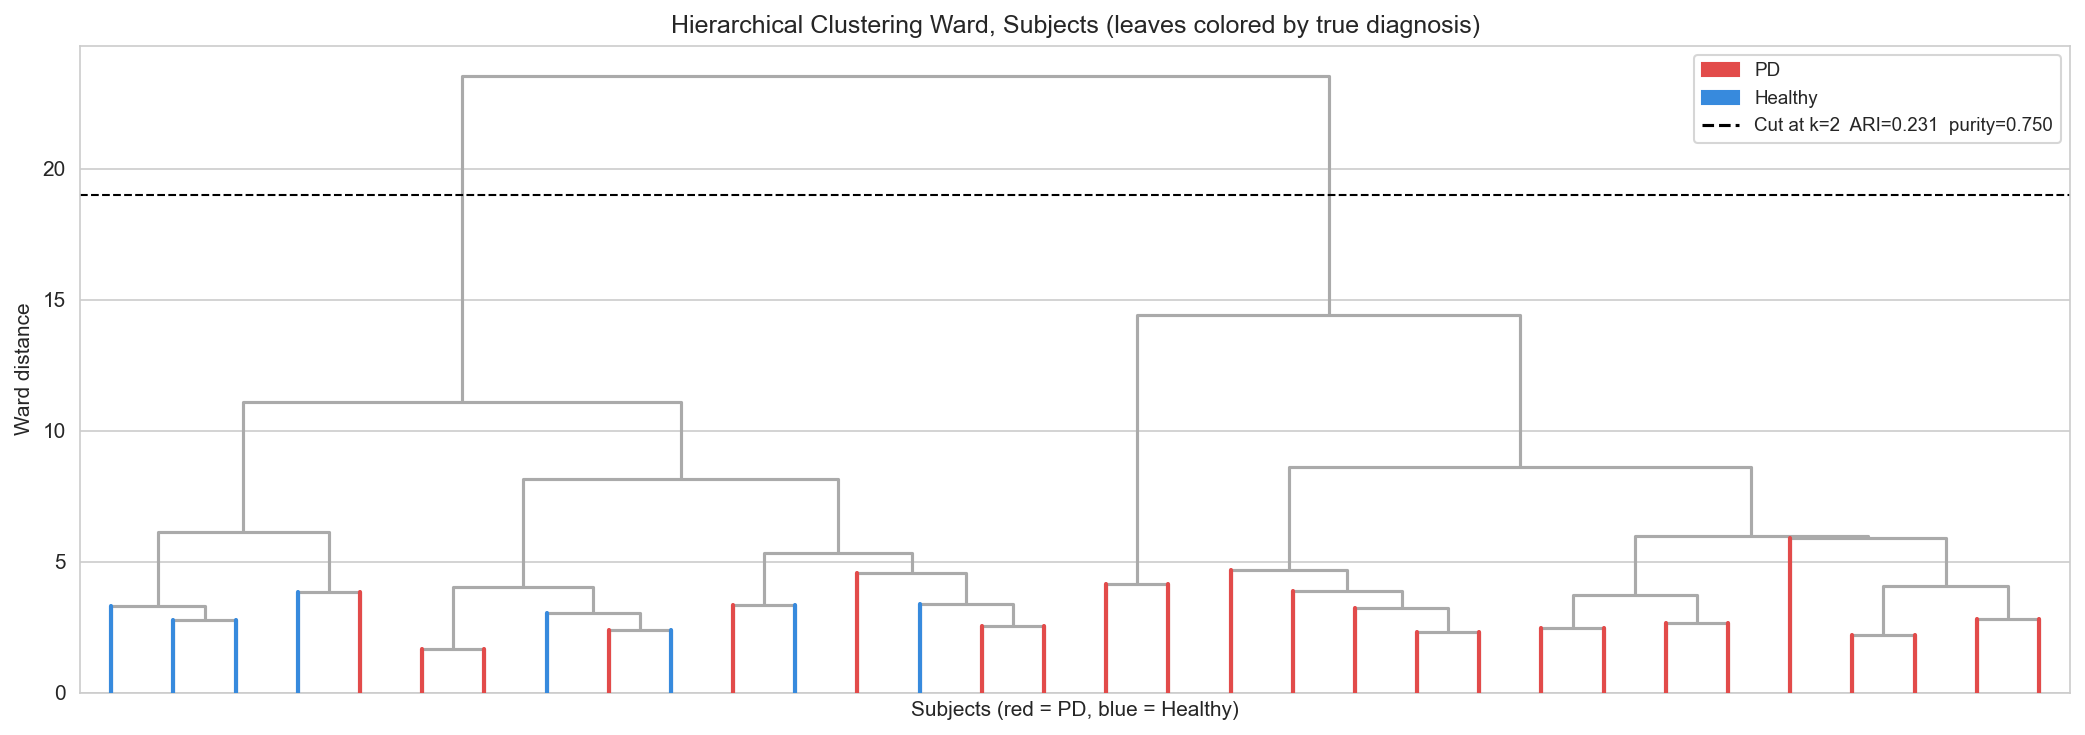

Hierarchical (Ward, k=2, subject level)
  ARI    : 0.231
  Purity : 0.750
  Cluster 0: 16 subjects, PD=16, Healthy=0
  Cluster 1: 16 subjects, PD=8, Healthy=8


In [8]:
Z_subj = linkage(X_scaled_subj, method='ward')

leaf_colors_subj = {i: (PALETTE["PD"] if y_true_grouped[i] == 1 else PALETTE["Healthy"])
                    for i in range(len(y_true_grouped))}

fig, ax = plt.subplots(figsize=(14, 5))
dn_subj = dendrogram(
    Z_subj,
    ax=ax,
    link_color_func=lambda k: '#aaaaaa',
    leaf_rotation=90,
    leaf_font_size=7,
    no_labels=True,
)

leaf_stem_map = {}
for icoord, dcoord in zip(dn_subj['icoord'], dn_subj['dcoord']):
    if dcoord[0] == 0:
        leaf_stem_map[icoord[0]] = dcoord[1]
    if dcoord[3] == 0:
        leaf_stem_map[icoord[3]] = dcoord[2]

for pos, x in enumerate(sorted(leaf_stem_map)):
    leaf_idx = dn_subj['leaves'][pos]
    ax.plot([x, x], [0, leaf_stem_map[x]],
            color=leaf_colors_subj[leaf_idx], linewidth=2.0, zorder=5)

# Hierarchical k=2 metrics
hc2_subj    = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels_subj = hc2_subj.fit_predict(X_scaled_subj)
hc_ari_subj    = adjusted_rand_score(y_true_grouped, hc_labels_subj)
hc_purity_subj = cluster_purity(y_true_grouped, hc_labels_subj)

cut_height = (Z_subj[-1, 2] + Z_subj[-2, 2]) / 2
ax.axhline(cut_height, color='black', linestyle='--', linewidth=1)

pd_patch = mpatches.Patch(color=PALETTE["PD"],      label='PD')
he_patch = mpatches.Patch(color=PALETTE["Healthy"], label='Healthy')
ax.legend(handles=[pd_patch, he_patch,
                   plt.Line2D([0],[0], color='black', linestyle='--',
                              label=f'Cut at k=2  ARI={hc_ari_subj:.3f}  purity={hc_purity_subj:.3f}')],
          fontsize=9, loc='upper right')

ax.set_title('Hierarchical Clustering Ward, Subjects (leaves colored by true diagnosis)', fontsize=12)
ax.set_xlabel('Subjects (red = PD, blue = Healthy)', fontsize=10)
ax.set_ylabel('Ward distance', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/clustering_dendrogram_subject.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Hierarchical (Ward, k=2, subject level)')
print(f'  ARI    : {hc_ari_subj:.3f}')
print(f'  Purity : {hc_purity_subj:.3f}')
for c in [0, 1]:
    mask = hc_labels_subj == c
    n_pd = (y_true_grouped[mask] == 1).sum()
    n_he = (y_true_grouped[mask] == 0).sum()
    print(f'  Cluster {c}: {mask.sum()} subjects, PD={n_pd}, Healthy={n_he}')

Summary (Subject Level)

In [9]:
baseline_purity_subj = max((y_true_grouped==1).mean(), (y_true_grouped==0).mean())

summary_subj = pd.DataFrame([
    {
        'Method':     'K-Means (k=2)',
        'ARI':        round(ari_subj, 3),
        'Silhouette': round(sil_subj, 3),
        'Purity':     round(purity_subj, 3),
    },
    {
        'Method':     'Hierarchical/Ward (k=2)',
        'ARI':        round(hc_ari_subj, 3),
        'Silhouette': round(silhouette_score(X_scaled_subj, hc_labels_subj), 3),
        'Purity':     round(hc_purity_subj, 3),
    },
]).set_index('Method')

print('Clustering Summary (subject level)')
print(summary_subj.to_string())
print(f'\nBaseline purity (majority-class always): {baseline_purity_subj:.3f}')

Clustering Summary (subject level)
                           ARI  Silhouette  Purity
Method                                            
K-Means (k=2)            0.119       0.299    0.75
Hierarchical/Ward (k=2)  0.231       0.294    0.75

Baseline purity (majority-class always): 0.750


Recording-Level Analysis

Three sub-analyses:
- (a) K-Means k=2 on all recordings -> recording-level ARI/purity/silhouette  
- (b) Collapse recording-level cluster assignments to one decision per subject via
  majority vote, then evaluate against subject-level labels  
- (c) Comparison table: subject-level vs recording-level vs majority-vote

In [10]:
# (a) Recording-level K-Means k=2
km2_rec           = KMeans(n_clusters=2, random_state=42, n_init=50)
cluster_labels_rec = km2_rec.fit_predict(X_scaled_rec)

ari_rec    = adjusted_rand_score(y_true, cluster_labels_rec)
sil_rec    = silhouette_score(X_scaled_rec, cluster_labels_rec)
purity_rec = cluster_purity(y_true, cluster_labels_rec)

print('K-Means k=2 (recording level)')
print(f'  ARI       : {ari_rec:.3f}')
print(f'  Silhouette: {sil_rec:.3f}')
print(f'  Purity    : {purity_rec:.3f}')
print()
for c in [0, 1]:
    mask = cluster_labels_rec == c
    n_pd = (y_true[mask] == 1).sum()
    n_he = (y_true[mask] == 0).sum()
    print(f'  Cluster {c}: {mask.sum()} recordings, PD={n_pd}, Healthy={n_he}')

K-Means k=2 (recording level)
  ARI       : 0.123
  Silhouette: 0.314
  Purity    : 0.759

  Cluster 0: 86 recordings, PD=84, Healthy=2
  Cluster 1: 101 recordings, PD=58, Healthy=43


In [11]:
# (b) Majority-vote collapse: one cluster label per subject
df_vote = df[['subject']].copy()
df_vote['rec_cluster'] = cluster_labels_rec
subject_vote = (
    df_vote.groupby('subject')['rec_cluster']
    .agg(lambda x: int(pd.Series.mode(x)[0]))
)
vote_labels = subject_vote.loc[df_grouped['subject']].values

ari_vote    = adjusted_rand_score(y_true_grouped, vote_labels)
purity_vote = cluster_purity(y_true_grouped, vote_labels)

print('Recording clusters -> majority-vote per subject:')
print(f'  ARI    : {ari_vote:.3f}')
print(f'  Purity : {purity_vote:.3f}')
print()

# (c) Comparison table
comparison = pd.DataFrame([
    {
        'Analysis unit':  'Subject means (n=32)',
        'ARI':            round(ari_subj, 3),
        'Silhouette':     round(sil_subj, 3),
        'Purity':         round(purity_subj, 3),
        'Note':           'Honest unit, matches LOSO-CV'
    },
    {
        'Analysis unit':  'Recordings (n≈185)',
        'ARI':            round(ari_rec, 3),
        'Silhouette':     round(sil_rec, 3),
        'Purity':         round(purity_rec, 3),
        'Note':           'Optimistic, correlated within-subject recordings'
    },
    {
        'Analysis unit':  'Recordings -> majority vote (n=32)',
        'ARI':            round(ari_vote, 3),
        'Silhouette':     '—',
        'Purity':         round(purity_vote, 3),
        'Note':           'Recording model collapsed to subject predictions'
    },
]).set_index('Analysis unit')

print('Comparison: subject-level vs recording-level vs majority-vote')
print(comparison.to_string())

Recording clusters -> majority-vote per subject:
  ARI    : 0.171
  Purity : 0.750

Comparison: subject-level vs recording-level vs majority-vote
                                      ARI Silhouette  Purity                                              Note
Analysis unit                                                                                                 
Subject means (n=32)                0.119      0.299   0.750                      Honest unit, matches LOSO-CV
Recordings (n≈185)                  0.123      0.314   0.759  Optimistic, correlated within-subject recordings
Recordings -> majority vote (n=32)  0.171          —   0.750  Recording model collapsed to subject predictions
